## Debugging of Vulkaneifel SMEW

In [1]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "wrappers_postprocessing" / "zeroex_input_data_wrapper.py").is_file()
)
sys.path.insert(0, str(repo_root / "wrappers_postprocessing"))

import zeroex_input_data_wrapper as wp

--------------------------------------------------------------------------------------
Reading input files for Vulkaneifel ...
Input files read successfully.
--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
Running SMEW for Vulkaneifel ...


/Users/estebangaitan/Documents/Github/SMEW_ZeroEx/SMEW/smew/biogeochem.py:423: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(equations,x0, xtol=1e-12)
/Users/estebangaitan/Documents/Github/SMEW_ZeroEx/SMEW/smew/biogeochem.py:430: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  sol = fsolve(equations, x0, xtol=1e-14)


Weathered fraction in year  0 : [0.] idx: [0]
Weathered fraction in year  1 : [5.89801043] idx: [52560]
Weathered fraction in year  2 : [6.6985618] idx: [105120]
Weathered fraction in year  3 : [7.08509067] idx: [157680]
Weathered fraction in year  4 : [7.41485433] idx: [210240]
Weathered fraction in year  5 : [] idx: []
Model run finished.
--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
Plotting outputs for Vulkaneifel ...
Figures completed.
--------------------------------------------------------------------------------------


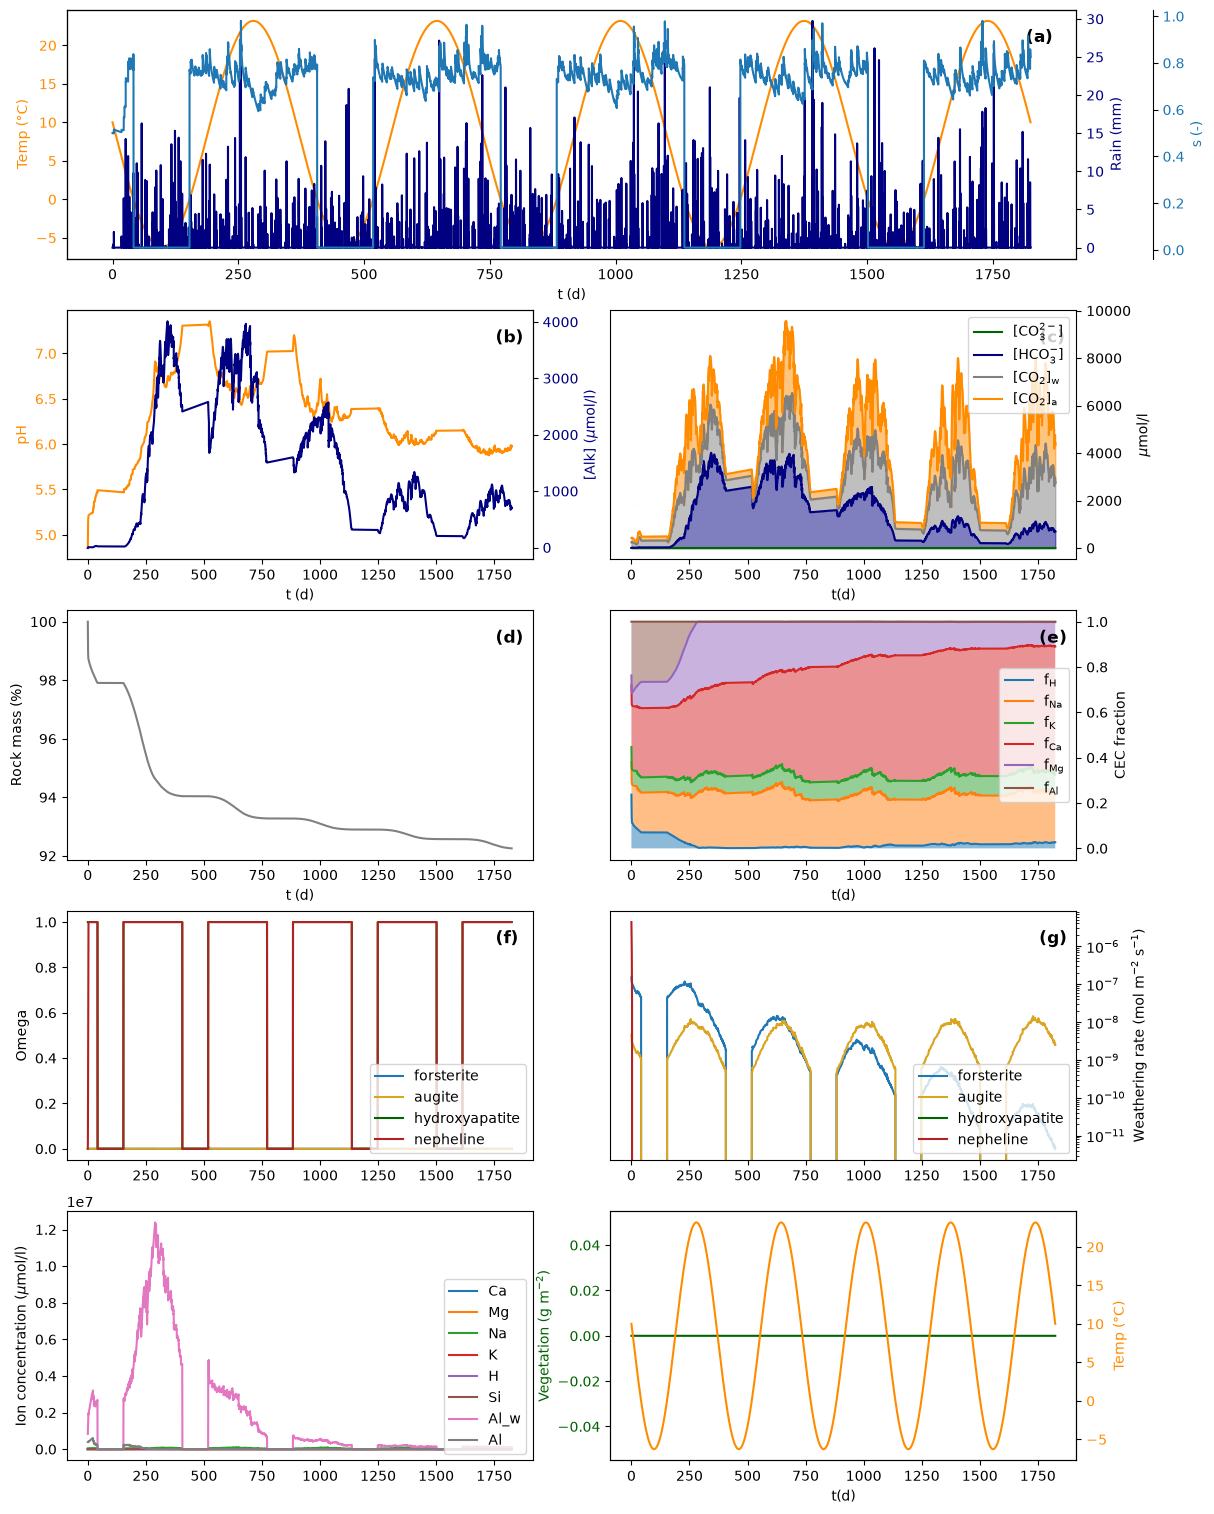

In [ ]:
project = 'Vulkaneifel'
field_name = 'Field C'

input_data = wp.read_input_data(project_name=project,value_col=field_name)
output_data = wp.run_SMEW(project_name=project,input_data=input_data)
wp.create_plots(project_name=project,model_results=output_data)

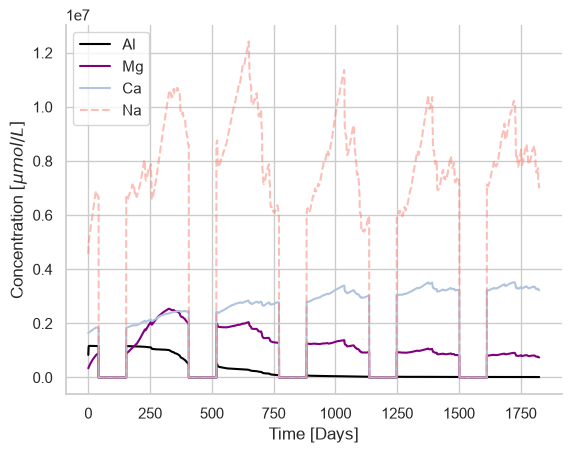

In [41]:
#Al tot corrected
Al_corr = output_data['Al_tot']/1000

sns.set_theme('notebook')
sns.set_style('whitegrid')


sns.lineplot(data=output_data,x='t',y=Al_corr,color='black',label='Al')
sns.lineplot(data=output_data,x='t',y='Mg_tot',color='purple',label='Mg')
sns.lineplot(data=output_data,x='t',y='Ca_tot',color='lightsteelblue',label='Ca')
sns.lineplot(data=output_data,x='t',y='Na_tot',color='salmon',linestyle='--',alpha=0.5,label='Na')
#sns.lineplot(data=output_data,x='t',y='H')

#formatting
plt.xlabel('Time [Days]')
plt.ylabel(r'Concentration $[\mu mol / L]$')
sns.despine()

## Conclusion

The Al-issue seems to be a **units issue**. The code in the case of Al uses both *conv_mol* and *conv_Al* – Check both `Example.ipynb` and `biochem.py`. Once the Al concentration is divided by 1000 to convert it to micromols $\mu$, the concentration shows values in the range of the other cations.